# Supplementary Figure S38: `s38_controversial_results`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_controversial_results.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

This figure reports the controversial-accentuation experiment site by site. Each of the 140 stimuli (7 aIT sites in Monkey R, 10 seeds, 2 target models) was synthesized so that one encoding model predicted a high response while the other predicted a low one, forcing standard ResNet50 and ResNet50-Robust to disagree about the same image. Panels a to g plot the measured, z-scored response of each site against each model's prediction (Lasso readouts), and panel h collects the per-site correlations for both models and compares them with a Wilcoxon signed-rank test. Everything comes from one table returned by `L.load_controversial_table()`, which carries the measured responses and their SEMs, both models' predictions, and per-site and pooled noise ceilings.

## What the script says about itself

Supp fig (controversial_results) - controversial-accentuation results across the 7 targeted aIT sites.

For each targeted aIT site the two encoding models' predictions are pitted against the (anchorDay-standardized) measured neural response to the controversial accentuations. The Robust ResNet50 predictions track the neural response (positive correlation); standard ResNet50 predictions anti-track it (negative correlation). Panels a-g show the per-site model-prediction vs neural-response clouds (both models, Lasso encoders, raw prediction units) with least-squares fits and per-site correlations. Panel h summarizes the per-site correlations for the two models with paired lines, group means, and the Wilcoxon signed-rank test; grey dashed lines mark the achievable +/- noise-ceiling envelope pooled over sites.

Reads loader.load_controversial_table(). Robust-favoring vs standard-favoring stimuli are distinguished by marker fill in the scatter panels; correlations pool both families per site (matching the companion controversial figure).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`C_R50` and `C_ROBUST`, with their faded variants, are copied from the companion controversial figure (S36) so legend markers match across the two figures. The site list is not hard-coded: `UNITS` is filled from the table at load time. The font-size constants are the only things a reader is likely to adjust.

In [2]:
import os

import argparse

import numpy as np

import matplotlib; matplotlib.use('Agg')



import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

from matplotlib.lines import Line2D

from scipy import stats

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.preproc import loader as L

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR,
                       save_fig)

apply_figure_style()

_M = _fig('controversial_results'); STEM = output_name('controversial_results')



# exact colors + fades from the companion controversial figure so the legend markers match
C_R50, C_ROBUST = '#FF9D1E', '#8DC63F'

C_R50_FADE, C_ROBUST_FADE = '#FFD9A6', '#DCEFB4'

FS_TITLE, FS_AX, FS_TICK, FS_RVAL, FS_LEG = 7, 6, 5.5, 5.5, 5.5

FS_NC = 5.0   # per-site noise-ceiling subtitle

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

Two small helpers load and correlate, and two panel functions draw a site scatter and the summary.

### `_r(x, y)`

A guarded Pearson correlation: returns NaN unless both inputs vary and there are at least five points.

In [3]:
def _r(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    return stats.pearsonr(x, y)[0] if x.std() > 0 and y.std() > 0 and len(x) >= 5 else np.nan

More configuration used by the functions below.

In [4]:
# ── load ──────────────────────────────────────────────────────────────────────
# Table columns the panel helpers read; filled by _load() at call time (was import-time work).
UNITS = stim = unit = neural = sem = pred_r50 = pred_rob = is_r50fav = ncr = ncr_pool = None

### `_load()`

Reads the controversial table into module-level arrays that the panel helpers use. A stimulus is tagged as ResNet50-favoring when its name contains `max_r50`; everything else is Robust-favoring. It also pulls the per-site ceiling (`ncr`) and the pooled ceiling (`ncr_pool`), both expressed as Pearson r.

In [5]:
def _load():
    global UNITS, stim, unit, neural, sem, pred_r50, pred_rob, is_r50fav, ncr, ncr_pool
    d = L.load_controversial_table()
    t = d['table']
    UNITS = [int(u) for u in d['units']]
    stim = np.asarray(t['stim']).astype(str)
    unit = np.asarray(t['unit']).astype(int)
    neural = np.asarray(t['neural'], float)
    sem = np.asarray(t['sem'], float)
    pred_r50 = np.asarray(t['RN50_Lasso'], float)       # standard-model prediction (Lasso)
    pred_rob = np.asarray(t['RN50rbst_Lasso'], float)   # robust-model prediction (Lasso)
    # robust-favoring vs standard-favoring stimulus family
    is_r50fav = np.char.find(stim, 'max_r50') >= 0
    ncr = d['ceilings']['nc_r_controversial']           # per-unit achievable ceiling (Pearson r)
    ncr_pool = d['ceilings']['nc_r_pooled']

### `scatter(ax, u, show_xlabel, show_ylabel)`

── per-site scatter ────────────────────────────────────────────────────────

Draws one site. Marker shape encodes the predicting model (circles for ResNet50, squares for Robust); the marker is fully coloured when the stimulus was synthesized in that model's favour and faded otherwise. Grey error bars give the SEM of the measured response, one least-squares line is fitted per model, and the two correlations are boxed in the top right. Note that each correlation pools both stimulus families for the site, matching S36. The per-site noise ceiling is printed as a small subtitle.

In [6]:
# ── per-site scatter ────────────────────────────────────────────────────────
def scatter(ax, u, show_xlabel, show_ylabel):
    m = unit == u
    y = neural[m]; ye = sem[m]; r50fav = is_r50fav[m]   # True = ResNet50-favoring stimulus family
    # marker scheme copied from the companion controversial figure: shape encodes prediction
    # model (o=R50, s=Robust), full colour when the prediction model matches the stimulus
    # family, faded when it does not.
    for pred, mk, base, fade, match in [(pred_r50[m], 'o', C_R50, C_R50_FADE, r50fav),
                                        (pred_rob[m], 's', C_ROBUST, C_ROBUST_FADE, ~r50fav)]:
        ax.errorbar(pred, y, yerr=ye, fmt='none', ecolor='#BBBBBB', elinewidth=0.5,
                    alpha=0.7, capsize=0, zorder=2)
        ax.scatter(pred[match], y[match], s=14, facecolors=base, marker=mk, edgecolors='black',
                   linewidths=0.4, alpha=0.95, zorder=4)
        ax.scatter(pred[~match], y[~match], s=14, facecolors=fade, marker=mk, edgecolors='black',
                   linewidths=0.4, alpha=0.95, zorder=4)
        sl, b, _, _, _ = stats.linregress(pred, y)
        xs = np.linspace(pred.min(), pred.max(), 50)
        ax.plot(xs, sl * xs + b, color=base, lw=1.2, zorder=5)
    r5 = _r(pred_r50[m], y); rb = _r(pred_rob[m], y)
    ax.axhline(0, color='#E5E5E5', lw=0.6, zorder=0)
    ax.axvline(0, color='#E5E5E5', lw=0.6, zorder=0)
    tk = dict(transform=ax.transAxes, ha='right', va='top', fontsize=FS_RVAL,
              fontweight='bold', fontfamily=FONT_FAMILY, linespacing=1.25)
    ax.text(0.97, 0.97, f'r = {r5:+.2f}\nr = {rb:+.2f}', color='none', zorder=7,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#CCC',
                      lw=0.5, alpha=0.92), **tk)
    ax.text(0.97, 0.97, f'r = {r5:+.2f}\n ', color=C_R50, zorder=8, **tk)
    ax.text(0.97, 0.97, f' \nr = {rb:+.2f}', color=C_ROBUST, zorder=8, **tk)
    ax.set_title(f'Site {u} (aIT)', fontsize=FS_TITLE, fontfamily=FONT_FAMILY, pad=11)
    # per-site achievable noise ceiling (Pearson r over the 20 controversial stims), small
    # subtitle centred just below the panel title
    ax.text(0.5, 1.015, f'noise ceiling $r$ = {ncr[u]:.2f}', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=FS_NC, color='#555555', fontfamily=FONT_FAMILY)
    ax.tick_params(labelsize=FS_TICK, length=2, pad=1)
    if show_xlabel:
        ax.set_xlabel('Predicted response (z)', fontsize=FS_AX, fontfamily=FONT_FAMILY)
    if show_ylabel:
        ax.set_ylabel('Measured neural (z)', fontsize=FS_AX, fontfamily=FONT_FAMILY)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

### `summary(ax)`

── summary ─────────────────────────────────────────────────────────────────

Plots the seven per-site correlations for each model at two x positions, joins paired values with grey lines, marks group means with diamonds and a connecting black line, and annotates the mean values. Dotted lines show plus and minus the pooled noise ceiling. The Wilcoxon signed-rank test is run on the seven paired correlations and its p-value sits above a bracket. Returns the two r vectors and the p-value so the assembly can print them.

In [7]:
# ── summary ─────────────────────────────────────────────────────────────────
def summary(ax):
    r5 = np.array([_r(pred_r50[unit == u], neural[unit == u]) for u in UNITS])
    rb = np.array([_r(pred_rob[unit == u], neural[unit == u]) for u in UNITS])
    # achievable +/- noise-ceiling envelope (pooled over the 7 aIT sites), dashed lines only
    ax.axhline(ncr_pool, color='#AAAAAA', lw=0.6, ls=':', zorder=1)
    ax.axhline(-ncr_pool, color='#AAAAAA', lw=0.6, ls=':', zorder=1)
    for a, b in zip(r5, rb):
        ax.plot([0, 1], [a, b], color='#999999', lw=0.7, alpha=0.7, zorder=2)
    ax.scatter([0] * len(r5), r5, s=28, c=C_R50, edgecolors='black', linewidths=0.4, zorder=4)
    ax.scatter([1] * len(rb), rb, s=28, c=C_ROBUST, edgecolors='black', linewidths=0.4, zorder=4)
    ax.scatter([0], [r5.mean()], marker='D', s=70, c=C_R50, edgecolors='black', linewidths=0.8, zorder=6)
    ax.scatter([1], [rb.mean()], marker='D', s=70, c=C_ROBUST, edgecolors='black', linewidths=0.8, zorder=6)
    ax.plot([0, 1], [r5.mean(), rb.mean()], color='black', lw=1.4, zorder=5)
    # mean r annotations beside each group's diamond
    ax.annotate(f'{r5.mean():+.2f}', (0, r5.mean()), xytext=(-6, 0),
                textcoords='offset points', ha='right', va='center',
                fontsize=FS_RVAL, fontweight='bold', color=C_R50, fontfamily=FONT_FAMILY)
    ax.annotate(f'{rb.mean():+.2f}', (1, rb.mean()), xytext=(6, 0),
                textcoords='offset points', ha='left', va='center',
                fontsize=FS_RVAL, fontweight='bold', color=C_ROBUST, fontfamily=FONT_FAMILY)
    ax.axhline(0, color='#555555', lw=0.8, ls='--', zorder=1)
    # Wilcoxon signed-rank across the 7 sites
    p = stats.wilcoxon(rb, r5).pvalue
    ymax = max(r5.max(), rb.max())
    sig_y = max(ymax, ncr_pool) + 0.12
    ax.plot([0, 0, 1, 1], [sig_y - 0.04, sig_y, sig_y, sig_y - 0.04], color='black', lw=0.8)
    ax.text(0.5, sig_y + 0.015, f'p = {p:.3f}', ha='center', va='bottom',
            fontsize=FS_RVAL, fontweight='bold', fontfamily=FONT_FAMILY)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['ResNet50', 'RN50-Robust'],
                                              fontsize=FS_AX, fontfamily=FONT_FAMILY)
    for tk, c in zip(ax.get_xticklabels(), [C_R50, C_ROBUST]):
        tk.set_color(c); tk.set_fontweight('bold')
    ax.set_ylabel('Correlation with\nneural response (r)', fontsize=FS_AX, fontfamily=FONT_FAMILY)
    ymag = max(abs(r5.min()), abs(rb.min()), ncr_pool, sig_y) + 0.12
    ax.set_xlim(-0.55, 1.55); ax.set_ylim(-ymag, ymag)
    ax.set_title('Per-site summary', fontsize=FS_TITLE, fontfamily=FONT_FAMILY, pad=3)
    ax.tick_params(labelsize=FS_TICK, length=2, pad=1)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    return r5, rb, p

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

The canvas is a 2 x 4 grid. The first seven cells (top row, then bottom row left to right) hold the site scatters in `UNITS` order and the bottom-right cell holds the summary. A title, a four-entry legend and an n-count note form a header; after a first draw their measured heights are used to re-space them so the three vertical gaps are equal.

In [8]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the table, creates the figure and grid, draws the seven scatters (x labels only on the bottom row and on the top-right panel, which sits above the summary rather than another scatter), draws the summary, adds the header text and legend, places the panel letters, then renders once and re-flows the header so the gaps match.

In [9]:
_load()
FIGHEIGHT_MM = 120.0
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, FIGHEIGHT_MM * MM), facecolor=FIG_FACECOLOR)
gs = GridSpec(2, 4, figure=fig, left=0.075, right=0.985, top=0.82, bottom=0.10,
              wspace=0.42, hspace=0.40)

# panels a-g: 7 site scatters ; panel h: summary
cells = [(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2)]
top_axes = []
for i, (u, (r, c)) in enumerate(zip(UNITS, cells)):
    ax = fig.add_subplot(gs[r, c])
    # bottom-row scatters and top-row col-3 (which sits above the summary, not a scatter)
    scatter(ax, u, show_xlabel=(r == 1 or (r, c) == (0, 3)), show_ylabel=(c == 0))
    if r == 0:
        top_axes.append(ax)
ax_sum = fig.add_subplot(gs[1, 3])
r5, rb, pval = summary(ax_sum)

# header: title, legend, dataset-size note. Placed at provisional positions (va='top' so each
# y is the box's TOP edge), then re-flowed so the three whitespace gaps -- title->legend,
# legend->note, note->top-of-first-row -- are identical.
title_txt = fig.text(0.5, 0.99, _M['title'], fontsize=FS_TITLE + 2, fontweight='bold',
                     ha='center', va='top', fontfamily=FONT_FAMILY)
note_txt = fig.text(0.5, 0.90, r'$n$ = 140 stimuli   (7 sites $\times$ 10 seeds $\times$ 2 target models)',
                    fontsize=FS_LEG, ha='center', va='top', fontfamily=FONT_FAMILY, color='#555555')
# legend markers + text identical to the companion controversial figure (boxed, 4 entries)
leg = [('o', C_R50, 'R50 pred, R50 stim'), ('o', C_R50_FADE, 'R50 pred, Robust stim'),
       ('s', C_ROBUST, 'Robust pred, Robust stim'), ('s', C_ROBUST_FADE, 'Robust pred, R50 stim')]
handles = [Line2D([0], [0], marker=mk, linestyle='none', markerfacecolor=fc, markeredgecolor='black',
                  markeredgewidth=0.6, markersize=6, label=lab) for mk, fc, lab in leg]
lg = fig.legend(handles=handles, loc='upper center', ncol=4,
                prop=dict(family=FONT_FAMILY, size=FS_LEG),
                frameon=True, bbox_to_anchor=(0.5, 0.95), columnspacing=1.25,
                handletextpad=0.4, borderaxespad=0)
lg.get_frame().set_edgecolor('#CCC'); lg.get_frame().set_facecolor('white')

# panel letters
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
all_cells = cells + [(1, 3)]
top_letters = []
for (r, c), let in zip(all_cells, letters):
    pos = gs[r, c].get_position(fig)
    lt = fig.text(pos.x0 - 0.028, pos.y1 + 0.018, let, ha='left', va='bottom',
                  fontsize=10, fontweight='bold', fontfamily=FONT_FAMILY)
    if r == 0:
        top_letters.append(lt)

# equalise the title/legend/note/row-1 whitespace gaps from measured element heights
fig.canvas.draw()
_rend = fig.canvas.get_renderer(); _inv = fig.transFigure.inverted()
def _frac_h(obj):
    bb = obj.get_window_extent(_rend)
    return _inv.transform((0, bb.y1))[1] - _inv.transform((0, bb.y0))[1]
def _frac_top(obj):
    return _inv.transform((0, obj.get_window_extent(_rend).y1))[1]
row1_top = max([_frac_top(a.title) for a in top_axes] + [_frac_top(lt) for lt in top_letters])
h_title, h_leg, h_note = _frac_h(title_txt), _frac_h(lg), _frac_h(note_txt)
title_top = 0.99
gap = (title_top - h_title - h_leg - h_note - row1_top) / 3.0
legend_top = title_top - h_title - gap
note_top = legend_top - h_leg - gap
title_txt.set_y(title_top)
lg.set_bbox_to_anchor((0.5, legend_top), transform=fig.transFigure)
note_txt.set_y(note_top)

**Step 2**

Saves the figure and prints the two mean correlations, the Wilcoxon p-value and the number of sites.

In [10]:
out = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print('robust-model mean r =', round(rb.mean(), 4))
print('standard-model mean r =', round(r5.mean(), 4))
print('Wilcoxon p =', round(pval, 4), '; n sites =', len(UNITS))
print('saved ->', out)
png = out

robust-model mean r = 0.3774
standard-model mean r = -0.3226
Wilcoxon p = 0.0156 ; n sites = 7
saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s38_controversial_results.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s38_controversial_results.png` in the output directory).

In panels a to g the green Robust fit should rise with the measured response and the orange ResNet50 fit should fall. In panel h the green points sit above zero and the orange points below it; the caption gives means of -0.32 for ResNet50 and +0.38 for RN50-Robust with Wilcoxon p = 0.016. The dotted ceiling lines show how much of the achievable correlation each model reaches.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s38_controversial_results.png


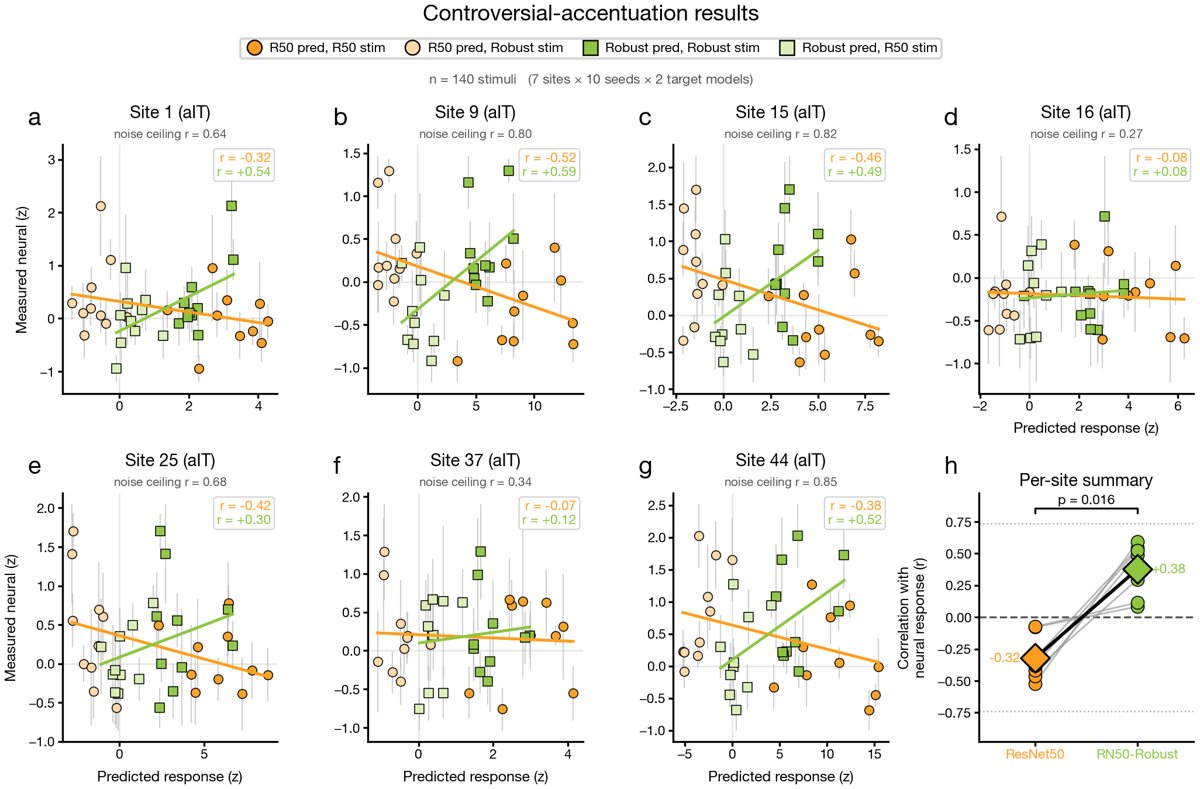

In [11]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S38. Controversial-accentuation results.** Site-by-site results of the controversial-accentuation experiment (Monkey R, aIT), in which each image was synthesized to drive one model's predicted response up while suppressing the other's, forcing the two models to make opposing predictions for the same stimuli. (A-G) Per-site scatter of measured neural response ($z$-scored, $y$) versus model prediction ($x$) for the seven targeted aIT sites (channels $1$, $9$, $15$, $16$, $25$, $37$, $44$; $n = 140$ stimuli total, $7$ sites $\times$ $10$ seeds $\times$ $2$ target models). Orange circles show standard ResNet50 predictions and green squares show ResNet50-Robust predictions (Lasso encoders); full color marks stimuli favoring the plotting model's family, faded color the opposing family. Lines represent least-squares fits per model, boxed values provide the per-site correlations per model, while the subtitle shows the maximum achievable correlation noise ceiling per site. Adversarially trained model predictions better track the neural response (positive $r$) while standard ResNet50 predictions are generally anticorrelated with it (negative $r$). (H) Per-site summaries: Pearson $r$ with the neural response for ResNet50 predictions versus ResNet50-Robust predictions, with diamonds and connecting line marking group means (ResNet50 $-0.32$, RN50-Robust $+0.38$). Gray dotted lines mark the pooled achievable $\pm$ noise-ceiling envelope. Adversarially trained models exceed standard across sites (Wilcoxon signed-rank $p = 0.016$), indicating that standard ResNet50's brain alignment derives largely from features shared with its adversarially trained counterpart.